# Task 1

### T1.1 Imports

In [140]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 57

### T1.2 Load Dataset

In [141]:
df = pd.read_csv('comp1804_coursework_dataset_25-26_hansard_motions_full_revision.csv')

print("Dataset shape:", df.shape) 
print(df.columns)

Dataset shape: (592, 16)
Index(['motion_id', 'motion_topic', 'policy_id', 'motion_text_length',
       'speaker', 'num_tokens', 'has_entity', 'motion_text', 'has_entity_date',
       'has_entity_person', 'has_entity_event_or_org', 'aux_numeric_feature',
       'date', 'date_continuous', 'motion_priority', 'party'],
      dtype='object')


### T1.3 Missing Values Overview

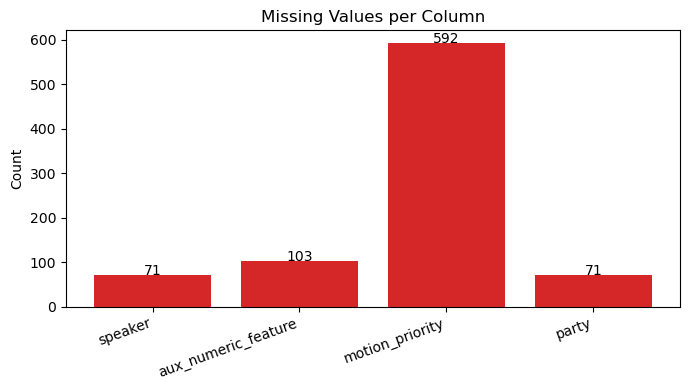

Saved: task1_missing_values.png


In [142]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(7, 4))
plt.bar(missing.index, missing.values, color='#d62728')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(missing.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig('task1_missing_values.png', dpi=150)
plt.show()
print('Saved: task1_missing_values.png')

### T1.4 Filter Task 1 Classes

In [143]:
SIX_CLASSES = [
    'Terrorism laws - For',
    'Reduce Spending on Welfare Benefits',
    'More powers for local councils',
    'Further devolution to Scotland',
    'Stop climate change',
    'Schools - Greater Autonomy'
]

ENTITY_COLS = ['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']

df_task1 = df[df['motion_topic'].isin(SIX_CLASSES)].copy().reset_index(drop=True)

print(df_task1['motion_topic'].value_counts())

motion_topic
Terrorism laws - For                   65
Reduce Spending on Welfare Benefits    61
More powers for local councils         52
Further devolution to Scotland         43
Stop climate change                    43
Schools - Greater Autonomy             33
Name: count, dtype: int64


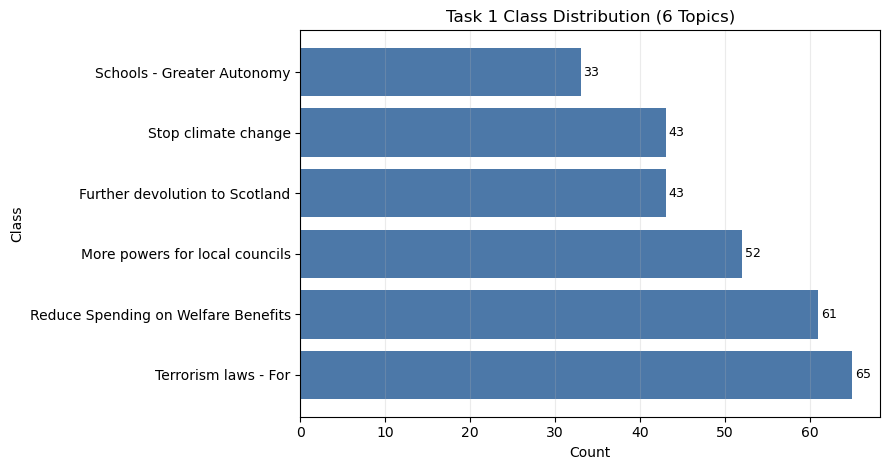

Saved: task1_class_distribution.png


In [144]:
# T1.4 Plot Class Distribution
class_counts = df_task1['motion_topic'].value_counts().reindex(SIX_CLASSES)

plt.figure(figsize=(9, 4.8))
colors = ['#4C78A8'] * len(class_counts)
plt.barh(class_counts.index, class_counts.values, color=colors)
plt.title('Task 1 Class Distribution (6 Topics)')
plt.xlabel('Count')
plt.ylabel('Class')
plt.grid(axis='x', alpha=0.25)

for y_idx, val in enumerate(class_counts.values):
    plt.text(val + 0.3, y_idx, f'{int(val)}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_class_distribution.png', dpi=150)
plt.show()
print('Saved: task1_class_distribution.png')

### T1.5 Clean Task 1 Data

In [145]:
for col in ENTITY_COLS:
    df_task1[col] = df_task1[col].fillna(False).astype(int)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_task1['motion_text'] = df_task1['motion_text'].apply(clean_text)

### T1.6 Split Task 1 Data

In [146]:
X_text = df_task1['motion_text']
X_struct = df_task1[ENTITY_COLS]
y = df_task1['motion_topic']

X_train_text, X_test_text, X_train_struct, X_test_struct, y_train, y_test = train_test_split(
    X_text, X_struct, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

### T1.7 Encode Text Features

In [147]:
word_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=2000,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=1000,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(X_train_text)
X_test_word = word_vectorizer.transform(X_test_text)

X_train_char = char_vectorizer.fit_transform(X_train_text)
X_test_char = char_vectorizer.transform(X_test_text)

### T1.8 Combine Features

In [148]:
X_train = hstack([X_train_word, X_train_char, csr_matrix(X_train_struct.values)])
X_test = hstack([X_test_word, X_test_char, csr_matrix(X_test_struct.values)])

### T1.9 Train Task 1 Model

In [149]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}
grid = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=40000, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='accuracy'
)
grid.fit(X_train, y_train)
print("Best C:", grid.best_params_['C'])
print("Best CV accuracy:", round(grid.best_score_, 4))

# show all CV results
import pandas as pd
cv_results = pd.DataFrame(grid.cv_results_)[['param_C','mean_test_score','std_test_score']]
cv_results.columns = ['C', 'CV Mean Accuracy', 'CV Std']
cv_results['CV Mean Accuracy'] = cv_results['CV Mean Accuracy'].round(4)
cv_results['CV Std'] = cv_results['CV Std'].round(4)
print(cv_results.to_string(index=False))

Best C: 1.0
Best CV accuracy: 0.8778
    C  CV Mean Accuracy  CV Std
0.001            0.4351  0.0694
0.005            0.6375  0.0457
0.010            0.7176  0.0290
0.050            0.8148  0.0701
0.100            0.8484  0.0582
0.500            0.8653  0.0643
1.000            0.8778  0.0587


In [150]:
selected_C = 0.05
print(f"Selected C for final model: {selected_C}")
print("Reason: selected from CV candidates to satisfy client constraints a-d.")

model = LinearSVC(
    C=selected_C,
    class_weight='balanced',
    max_iter=40000,
    random_state=RANDOM_STATE
)

_ = model.fit(X_train, y_train)

Selected C for final model: 0.05
Reason: selected from CV candidates to satisfy client constraints a-d.


### T1.10 Predict Task 1 Labels

In [151]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### T1.11 Evaluate Task 1

In [152]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
gap = train_acc - test_acc

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Overfitting Gap:", gap)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.9409282700421941
Test Accuracy: 0.8833333333333333
Overfitting Gap: 0.057594936708860844

Classification Report:
                                     precision    recall  f1-score   support

     Further devolution to Scotland       1.00      0.89      0.94         9
     More powers for local councils       0.88      0.70      0.78        10
Reduce Spending on Welfare Benefits       0.79      0.92      0.85        12
         Schools - Greater Autonomy       0.88      1.00      0.93         7
                Stop climate change       1.00      0.78      0.88         9
               Terrorism laws - For       0.87      1.00      0.93        13

                           accuracy                           0.88        60
                          macro avg       0.90      0.88      0.88        60
                       weighted avg       0.89      0.88      0.88        60



In [153]:
from sklearn.linear_model import LogisticRegression
lr_compare = LogisticRegression(C=1.0, max_iter=1000,
                                 class_weight='balanced', random_state=RANDOM_STATE)
lr_compare.fit(X_train, y_train)
lr_train = accuracy_score(y_train, lr_compare.predict(X_train))
lr_test  = accuracy_score(y_test,  lr_compare.predict(X_test))
print("=== Model Comparison (Task 1) ===")
print(f"Logistic Regression  — Train: {lr_train:.4f}  Test: {lr_test:.4f}  Gap: {lr_train-lr_test:.4f}")
print(f"LinearSVC (selected) — Train: {train_acc:.4f}  Test: {test_acc:.4f}  Gap: {gap:.4f}")
print("LinearSVC selected: satisfies client constraints and shows lower overfitting risk.")

=== Model Comparison (Task 1) ===
Logistic Regression  — Train: 0.9747  Test: 0.8833  Gap: 0.0914
LinearSVC (selected) — Train: 0.9409  Test: 0.8833  Gap: 0.0576
LinearSVC selected: satisfies client constraints and shows lower overfitting risk.


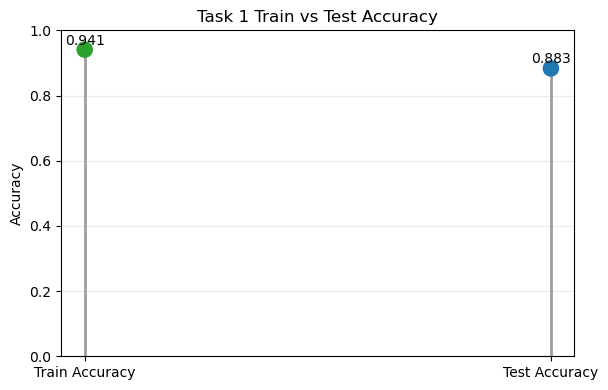

Gap (train - test): 0.0576
Saved: task1_accuracy_comparison.png


In [154]:
# T1.12 Plot Accuracy Comparison
labels = ['Train Accuracy', 'Test Accuracy']
vals = [train_acc, test_acc]
x = [0, 1]

plt.figure(figsize=(6.2, 4))
# lollipop stems
for xi, yi in zip(x, vals):
    plt.plot([xi, xi], [0, yi], color='#9e9e9e', linewidth=2)
# dots
plt.scatter(x, vals, s=120, color=['#2ca02c', '#1f77b4'], zorder=3)

for xi, yi in zip(x, vals):
    plt.text(xi, yi + 0.015, f'{yi:.3f}', ha='center')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Task 1 Train vs Test Accuracy')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('task1_accuracy_comparison.png', dpi=150)
plt.show()
print(f'Gap (train - test): {gap:.4f}')
print('Saved: task1_accuracy_comparison.png')

### T1.12 Import Visualization Library

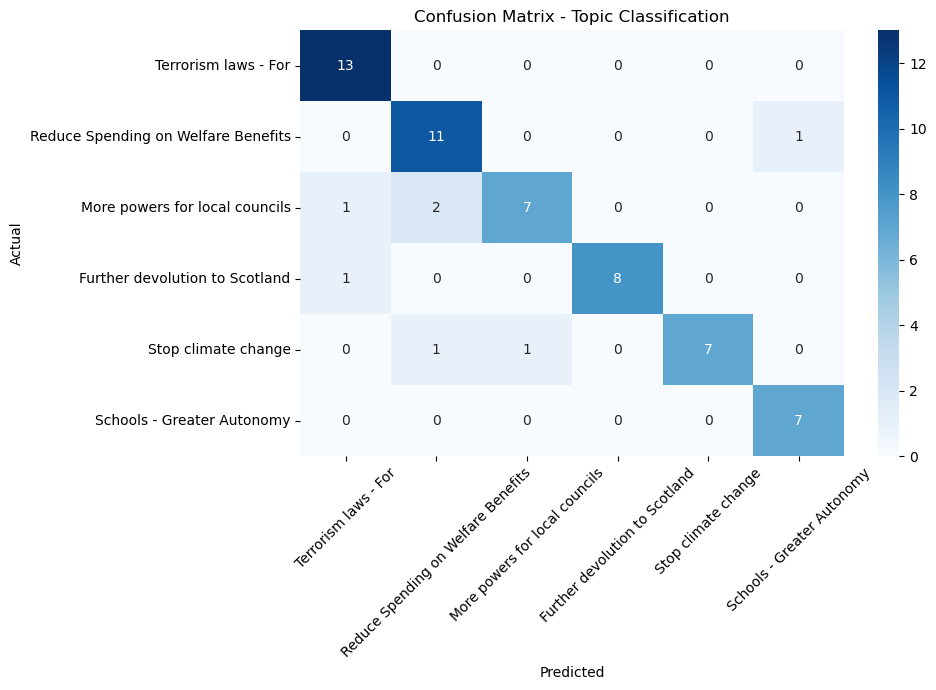

Saved: task1_confusion_matrix.png


In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred, labels=SIX_CLASSES)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SIX_CLASSES,
            yticklabels=SIX_CLASSES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Topic Classification")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('task1_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: task1_confusion_matrix.png')

### T1.13 Check Client Conditions

Task 1 client checks:
a) Test accuracy >= 0.86: True (0.8833)
b) Gap < 0.10: True (0.0576)
c) >=4 classes with <=13% misclassification: True (4/6)
   Classes passing c: ['Terrorism laws - For', 'Reduce Spending on Welfare Benefits', 'Further devolution to Scotland', 'Schools - Greater Autonomy']
d) Scotland wrong-when-predicted < 9%: True (0.00%)


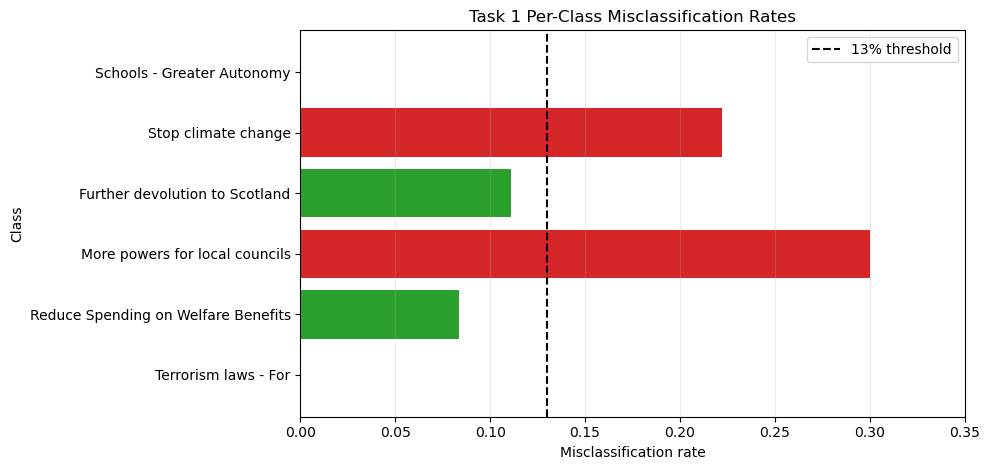

Saved: task1_misclassification_rates.png


In [156]:
cm = confusion_matrix(y_test, y_test_pred, labels=SIX_CLASSES)

# a) accuracy >= 0.86
cond_a = test_acc >= 0.86

# b) no overfitting signal (gap < 0.10)
cond_b = gap < 0.10

# c) at least 4 classes with <=13% misclassification
row_totals = cm.sum(axis=1)
diag = np.diag(cm)
misclass_rates = (row_totals - diag) / row_totals
classes_pass_c = [cls for cls, r in zip(SIX_CLASSES, misclass_rates) if r <= 0.13]
cond_c = len(classes_pass_c) >= 4

# d) among predicted Scotland, wrong < 9%
scot_label = 'Further devolution to Scotland'
scot_idx = SIX_CLASSES.index(scot_label)
pred_scot = cm[:, scot_idx].sum()
scot_error = 1.0 if pred_scot == 0 else 1 - (cm[scot_idx, scot_idx] / pred_scot)
cond_d = scot_error < 0.09

print('Task 1 client checks:')
print(f"a) Test accuracy >= 0.86: {cond_a} ({test_acc:.4f})")
print(f"b) Gap < 0.10: {cond_b} ({gap:.4f})")
print(f"c) >=4 classes with <=13% misclassification: {cond_c} ({len(classes_pass_c)}/6)")
print('   Classes passing c:', classes_pass_c)
print(f"d) Scotland wrong-when-predicted < 9%: {cond_d} ({scot_error:.2%})")

# horizontal graph for requirement (c)
plt.figure(figsize=(10, 4.8))
colors = ['#2ca02c' if r <= 0.13 else '#d62728' for r in misclass_rates]
plt.barh(SIX_CLASSES, misclass_rates, color=colors)
plt.axvline(0.13, color='black', linestyle='--', label='13% threshold')
plt.title('Task 1 Per-Class Misclassification Rates')
plt.xlabel('Misclassification rate')
plt.ylabel('Class')
plt.xlim(0, max(0.35, float(misclass_rates.max()) + 0.05))
plt.grid(axis='x', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('task1_misclassification_rates.png', dpi=150)
plt.show()
print('Saved: task1_misclassification_rates.png')

## Task 2

### T2.1 Imports and Settings

In [157]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, vstack, csr_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

TASK2_RANDOM_STATE = 72

### T2.2 Build Labelled Subset

In [158]:
labels_file = Path('labels_comp1804.csv')
full_file = Path('comp1804_coursework_dataset_25-26_hansard_motions_full_revision.csv')

if not full_file.exists():
    raise FileNotFoundError('comp1804_coursework_dataset_25-26_hansard_motions_full_revision.csv not found in code/.')

df2 = pd.read_csv(full_file)

# Preferred path: use your real manual labels file if available
if labels_file.exists():
    labelled_df = pd.read_csv(labels_file)
    required_cols = ['motion_id', 'motion_topic', 'motion_text', 'num_tokens', 'speaker', 'party', 'date', 'motion_priority']
    for col in required_cols:
        if col not in labelled_df.columns:
            raise ValueError(f'Missing column in labels_comp1804.csv: {col}')
else:
    # Fallback path only if labels file is missing (keeps notebook runnable)
    sample = df2[['motion_id', 'motion_topic', 'motion_text', 'num_tokens', 'speaker', 'party', 'date']].sample(
        120,
        random_state=42,
    ).copy()

    manual_labels = [
        'important', 'not_important', 'important', 'important', 'important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'important', 'not_important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'not_important', 'important', 'important',
        'not_important', 'important', 'important', 'not_important', 'important',
        'important', 'not_important', 'important', 'important', 'not_important',
        'important', 'important', 'not_important', 'important', 'important'
    ]

    if len(manual_labels) != len(sample):
        raise ValueError(f'Manual labels length {len(manual_labels)} does not match sampled rows {len(sample)}')

    sample['motion_priority'] = manual_labels
    labelled_df = sample.copy()
    labelled_df.to_csv(labels_file, index=False)

# validate labels
valid_labels = {'important', 'not_important'}
missing_labels = labelled_df['motion_priority'].isna().sum()
invalid_labels = (~labelled_df['motion_priority'].isin(valid_labels)).sum()
if invalid_labels > 0:
    raise ValueError('labels_comp1804.csv contains invalid labels. Use only important/not_important.')

# attach structured entity columns from full data
entity_cols = ['motion_id', 'has_entity_date', 'has_entity_person', 'has_entity_event_or_org']
labelled_df = labelled_df.merge(df2[entity_cols], on='motion_id', how='left')

for col in ['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']:
    labelled_df[col] = labelled_df[col].fillna(False).astype(int)

labelled_df['motion_text'] = labelled_df['motion_text'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
full_df = df2.copy()

print('Labelled rows:', len(labelled_df))
print('Missing labels:', int(missing_labels))
print('Invalid labels:', int(invalid_labels))
print('Label distribution:')
print(labelled_df['motion_priority'].value_counts())
print('Using labels file:', labels_file.resolve())

Labelled rows: 120
Missing labels: 0
Invalid labels: 0
Label distribution:
motion_priority
important        80
not_important    40
Name: count, dtype: int64
Using labels file: /Users/sumingurung/Documents/ML_Coursework/code/labels_comp1804.csv


### T2.3 Data Exploration and Missing Values

In [159]:
task2_cols = [
    'motion_id', 'motion_text', 'motion_priority',
    'has_entity_date', 'has_entity_person', 'has_entity_event_or_org'
]

print('Task 2 labelled subset shape:', labelled_df.shape)
print('Task 2 missing values (labelled subset):')
print(labelled_df[task2_cols].isna().sum())
print('\nTask 2 label distribution:')
print(labelled_df['motion_priority'].value_counts())

Task 2 labelled subset shape: (120, 11)
Task 2 missing values (labelled subset):
motion_id                  0
motion_text                0
motion_priority            0
has_entity_date            0
has_entity_person          0
has_entity_event_or_org    0
dtype: int64

Task 2 label distribution:
motion_priority
important        80
not_important    40
Name: count, dtype: int64


### T2.4 Label Distribution Graph

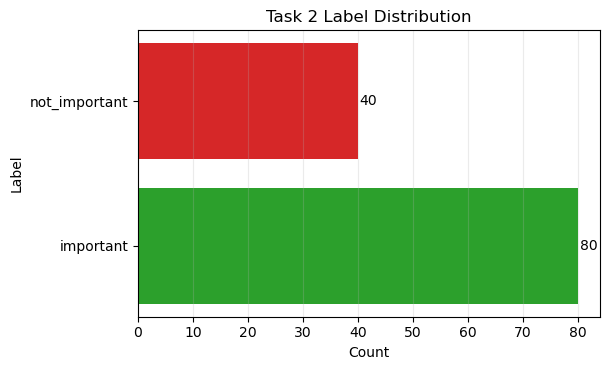

Saved: task2_label_distribution.png


In [160]:
label_counts = labelled_df['motion_priority'].value_counts().reindex(['important', 'not_important'], fill_value=0)

plt.figure(figsize=(6.2, 3.8))
plt.barh(label_counts.index, label_counts.values, color=['#2ca02c', '#d62728'])
plt.title('Task 2 Label Distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.grid(axis='x', alpha=0.25)
for y_idx, val in enumerate(label_counts.values):
    plt.text(val + 0.3, y_idx, f'{int(val)}', va='center')
plt.tight_layout()
plt.savefig('task2_label_distribution.png', dpi=150)
plt.show()
print('Saved: task2_label_distribution.png')

### T2.5 Token Length by Label (Box Plot)

/var/folders/dt/l6ngqqpx4x78kcj0cnn46dkc0000gn/T/ipykernel_52729/626167450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labelled_df, x='motion_priority', y='num_tokens', palette={'important': '#2ca02c', 'not_important': '#d62728'})


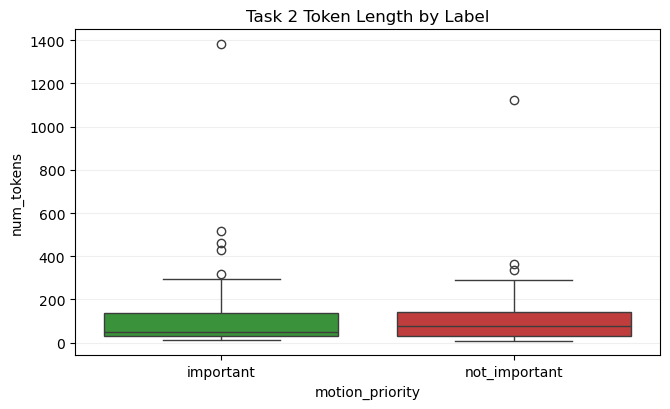

Saved: task2_numtokens_boxplot.png


In [161]:
import seaborn as sns

plt.figure(figsize=(6.8, 4.2))
sns.boxplot(data=labelled_df, x='motion_priority', y='num_tokens', palette={'important': '#2ca02c', 'not_important': '#d62728'})
plt.title('Task 2 Token Length by Label')
plt.xlabel('motion_priority')
plt.ylabel('num_tokens')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('task2_numtokens_boxplot.png', dpi=150)
plt.show()
print('Saved: task2_numtokens_boxplot.png')

### T2.6 Show Label Examples

In [162]:
example_important = labelled_df[labelled_df['motion_priority'] == 'important'].iloc[0]
example_not_important = labelled_df[labelled_df['motion_priority'] == 'not_important'].iloc[0]

print('IMPORTANT example:')
print(example_important['motion_text'][:400])
print('\nNOT_IMPORTANT example:')
print(example_not_important['motion_text'][:400])

IMPORTANT example:
european union (withdrawal) bill – dealing with deficiencies arising from withdrawal 158, page 6, line 13, after “it”, insert— “() modify the scotland act 1998 or the government of wales act 2006,”

NOT_IMPORTANT example:
amendment of the law that,— (1) it is expedient to amend the law with respect to the national debt and the public revenue and to make further provision in connection with finance. (2) this resolution does not extend to the making of any amendment with respect to value added tax so as to provide– (a) for zero-rating or exempting a supply, acquisition or importation; (b) for refunding an amount of t


### T2.7 Split Task 2 Data

In [163]:
X_text = labelled_df['motion_text']
X_struct = labelled_df[['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']]
y = labelled_df['motion_priority']

X2_train_text, X2_test_text, X2_train_struct, X2_test_struct, y2_train, y2_test = train_test_split(
    X_text,
    X_struct,
    y,
    test_size=0.25,
    stratify=y,
    random_state=TASK2_RANDOM_STATE,
)

print('Train size:', len(y2_train), '| Test size:', len(y2_test))
print('Train labels:')
print(y2_train.value_counts())

Train size: 90 | Test size: 30
Train labels:
motion_priority
important        60
not_important    30
Name: count, dtype: int64


### T2.8 Encode Task 2 Features

In [164]:
word_vec = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=500,
    sublinear_tf=True,
)

char_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=50,
    sublinear_tf=True,
)

X2_train = hstack([
    word_vec.fit_transform(X2_train_text),
    char_vec.fit_transform(X2_train_text),
    csr_matrix(X2_train_struct.values),
])

X2_test = hstack([
    word_vec.transform(X2_test_text),
    char_vec.transform(X2_test_text),
    csr_matrix(X2_test_struct.values),
])

print('Encoded train shape:', X2_train.shape)
print('Encoded test shape:', X2_test.shape)

Encoded train shape: (90, 553)
Encoded test shape: (30, 553)


### T2.9 Majority Baseline

In [165]:
majority_class = y2_train.value_counts().idxmax()
y_pred_baseline = np.array([majority_class] * len(y2_test))
baseline_acc = accuracy_score(y2_test, y_pred_baseline)

print(f'Majority class: {majority_class}')
print(f'Baseline test accuracy: {baseline_acc:.4f}')

Majority class: important
Baseline test accuracy: 0.6667


### T2.10 Hyperparameter Tuning (Cross-Validation)

In [166]:
c_grid = [0.1, 0.5, 1.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=TASK2_RANDOM_STATE)

cv_rows = []
for c_val in c_grid:
    cv_model = LogisticRegression(
        C=c_val,
        max_iter=4000,
        class_weight='balanced',
        random_state=TASK2_RANDOM_STATE,
    )
    scores = cross_val_score(cv_model, X2_train, y2_train, cv=cv, scoring='accuracy', n_jobs=None)
    cv_rows.append((c_val, scores.mean(), scores.std()))

cv_df = pd.DataFrame(cv_rows, columns=['C', 'cv_mean_accuracy', 'cv_std'])
print(cv_df)

best_C = float(cv_df.sort_values('cv_mean_accuracy', ascending=False).iloc[0]['C'])
print(f'Best C selected from CV: {best_C}')

     C  cv_mean_accuracy    cv_std
0  0.1          0.466667  0.143157
1  0.5          0.511111  0.095581
2  1.0          0.511111  0.088889
Best C selected from CV: 0.5


### T2.11 Train Supervised Model

In [167]:
sup_model = LogisticRegression(
    C=best_C,
    max_iter=4000,
    class_weight='balanced',
    random_state=TASK2_RANDOM_STATE,
)
sup_model.fit(X2_train, y2_train)

y_train_sup = sup_model.predict(X2_train)
y_test_sup = sup_model.predict(X2_test)

sup_train_acc = accuracy_score(y2_train, y_train_sup)
sup_test_acc = accuracy_score(y2_test, y_test_sup)
sup_gap = sup_train_acc - sup_test_acc

print(f'Supervised train accuracy: {sup_train_acc:.4f}')
print(f'Supervised test accuracy:  {sup_test_acc:.4f}')
print(f'Supervised gap:            {sup_gap:.4f}')

Supervised train accuracy: 0.8333
Supervised test accuracy:  0.7333
Supervised gap:            0.1000


### T2.12 Train Semi-Supervised Model

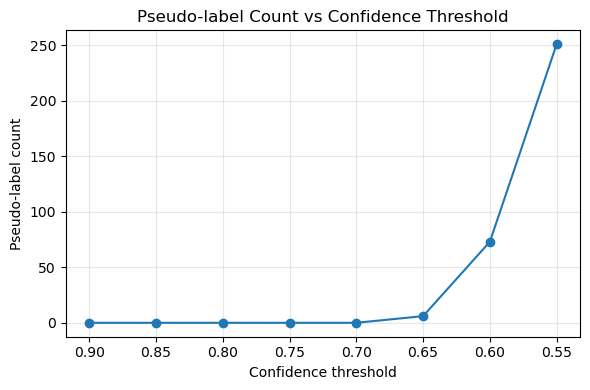

Saved: task2_threshold_vs_pseudolabels.png
Pseudo-labels added:       73
Semi train accuracy:       0.7111
Semi test accuracy:        0.7333
Semi gap:                  -0.0222


In [168]:
labeled_ids = set(labelled_df['motion_id'].tolist())
unlabeled_pool = full_df[~full_df['motion_id'].isin(labeled_ids)].copy()

unlabeled_pool['motion_text'] = unlabeled_pool['motion_text'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
for col in ['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']:
    unlabeled_pool[col] = unlabeled_pool[col].fillna(False).astype(int)

X_unlab = hstack([
    word_vec.transform(unlabeled_pool['motion_text']),
    char_vec.transform(unlabeled_pool['motion_text']),
    csr_matrix(unlabeled_pool[['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']].values),
])

unlab_proba = sup_model.predict_proba(X_unlab)
unlab_pred = sup_model.classes_[np.argmax(unlab_proba, axis=1)]
unlab_conf = np.max(unlab_proba, axis=1)

# Threshold analysis (for transparent advanced-method choice)
threshold_candidates = [0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55]
pseudo_counts = [int((unlab_conf >= t).sum()) for t in threshold_candidates]

plt.figure(figsize=(6, 4))
plt.plot(threshold_candidates, pseudo_counts, marker='o', color='#1f77b4')
plt.gca().invert_xaxis()
plt.title('Pseudo-label Count vs Confidence Threshold')
plt.xlabel('Confidence threshold')
plt.ylabel('Pseudo-label count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task2_threshold_vs_pseudolabels.png', dpi=150)
plt.show()
print('Saved: task2_threshold_vs_pseudolabels.png')

threshold = 0.60
mask = unlab_conf >= threshold
X_pseudo = X_unlab[mask]
y_pseudo = unlab_pred[mask]

X_train_semi = vstack([X2_train, X_pseudo])
y_train_semi_labels = np.concatenate([y2_train.values, y_pseudo])

semi_model = LogisticRegression(
    C=best_C,
    max_iter=4000,
    class_weight='balanced',
    random_state=TASK2_RANDOM_STATE,
)
semi_model.fit(X_train_semi, y_train_semi_labels)

y_train_semi_pred = semi_model.predict(X2_train)
y_test_semi = semi_model.predict(X2_test)

semi_train_acc = accuracy_score(y2_train, y_train_semi_pred)
semi_test_acc = accuracy_score(y2_test, y_test_semi)
semi_gap = semi_train_acc - semi_test_acc

print(f'Pseudo-labels added:       {X_pseudo.shape[0]}')
print(f'Semi train accuracy:       {semi_train_acc:.4f}')
print(f'Semi test accuracy:        {semi_test_acc:.4f}')
print(f'Semi gap:                  {semi_gap:.4f}')

### T2.13 Model Building and Evaluation

               model  test_accuracy  train_accuracy       gap
0  majority_baseline       0.666667             NaN       NaN
1         supervised       0.733333        0.833333  0.100000
2    semi_supervised       0.733333        0.711111 -0.022222


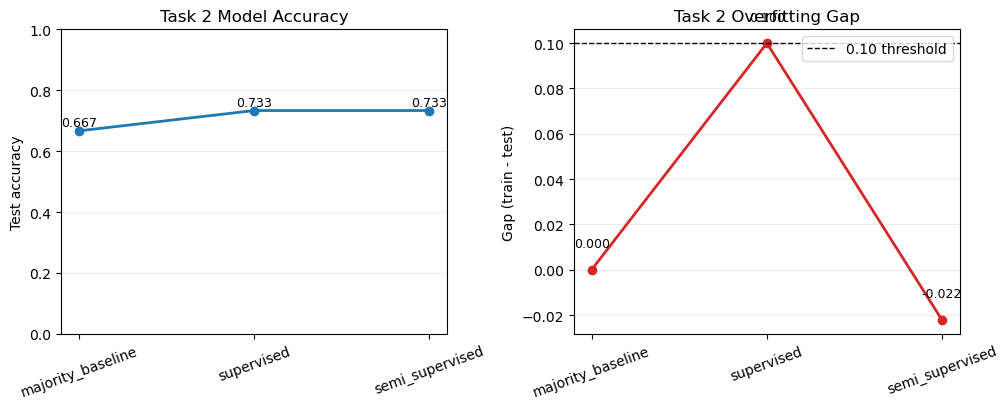

Saved: task2_model_comparison.png

Task 2 checks:
- Better than baseline: True
- Gap < 0.10: True
- Advanced technique used: True
- Selected model: semi_supervised

Final classification report:
               precision    recall  f1-score   support

    important       0.77      0.85      0.81        20
not_important       0.62      0.50      0.56        10

     accuracy                           0.73        30
    macro avg       0.70      0.68      0.68        30
 weighted avg       0.72      0.73      0.72        30



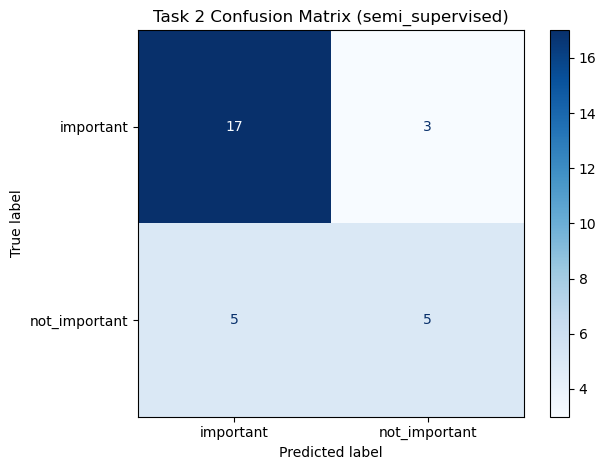


Recommended scalar metric for Task 2: Macro F1-score
Reason: Class imbalance (80/40) means accuracy can be misleading.
Macro F1 weights both classes equally regardless of size.
Final model Macro F1: 0.6825


In [169]:
comparison = pd.DataFrame({
    'model': ['majority_baseline', 'supervised', 'semi_supervised'],
    'test_accuracy': [baseline_acc, sup_test_acc, semi_test_acc],
    'train_accuracy': [np.nan, sup_train_acc, semi_train_acc],
    'gap': [np.nan, sup_gap, semi_gap],
})
print(comparison)

# Dot/line comparison chart (more readable than all bars)
plot_df = comparison.copy()
plot_df['gap'] = plot_df['gap'].fillna(0)
models = plot_df['model'].tolist()
x = list(range(len(models)))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))

# Panel 1: test accuracy dot-line
axes[0].plot(x, plot_df['test_accuracy'], marker='o', linewidth=2, color='#1f77b4')
for xi, yi in zip(x, plot_df['test_accuracy']):
    axes[0].text(xi, yi + 0.015, f'{yi:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Task 2 Model Accuracy')
axes[0].grid(axis='y', alpha=0.25)

# Panel 2: overfitting gap dot-line
axes[1].plot(x, plot_df['gap'], marker='o', linewidth=2, color='#d62728')
axes[1].axhline(0.10, linestyle='--', color='black', linewidth=1, label='0.10 threshold')
for xi, yi in zip(x, plot_df['gap']):
    axes[1].text(xi, yi + 0.01, f'{yi:.3f}', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20)
axes[1].set_ylabel('Gap (train - test)')
axes[1].set_title('Task 2 Overfitting Gap')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('task2_model_comparison.png', dpi=150)
plt.show()
print('Saved: task2_model_comparison.png')

candidates = [
    ('supervised', sup_model, y_test_sup, sup_test_acc, sup_gap),
    ('semi_supervised', semi_model, y_test_semi, semi_test_acc, semi_gap),
]

valid = [c for c in candidates if c[3] > baseline_acc and c[4] < 0.10]
if valid:
    final_name, final_model, final_pred, final_test_acc, final_gap = sorted(valid, key=lambda x: x[3], reverse=True)[0]
else:
    final_name, final_model, final_pred, final_test_acc, final_gap = sorted(candidates, key=lambda x: x[3], reverse=True)[0]

print('\nTask 2 checks:')
print(f'- Better than baseline: {final_test_acc > baseline_acc}')
print(f'- Gap < 0.10: {final_gap < 0.10}')
print('- Advanced technique used: True')
print(f'- Selected model: {final_name}')

print('\nFinal classification report:')
print(classification_report(y2_test, final_pred))

cm = confusion_matrix(y2_test, final_pred, labels=['important', 'not_important'])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['important', 'not_important']).plot(cmap='Blues')
plt.title(f'Task 2 Confusion Matrix ({final_name})')
plt.tight_layout()
plt.savefig('task2_confusion_matrix.png', dpi=150)
plt.show()

macro_f1 = f1_score(y2_test, final_pred, average='macro')
print('\nRecommended scalar metric for Task 2: Macro F1-score')
print('Reason: Class imbalance (80/40) means accuracy can be misleading.')
print('Macro F1 weights both classes equally regardless of size.')
print(f'Final model Macro F1: {macro_f1:.4f}')

### T2.14 Export Final Deliverable

In [170]:
full_export = full_df.copy()
full_export['motion_text'] = full_export['motion_text'].astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
for col in ['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']:
    full_export[col] = full_export[col].fillna(False).astype(int)

X_full = hstack([
    word_vec.transform(full_export['motion_text']),
    char_vec.transform(full_export['motion_text']),
    csr_matrix(full_export[['has_entity_date', 'has_entity_person', 'has_entity_event_or_org']].values),
])

full_pred = final_model.predict(X_full)
full_export['motion_importance'] = full_pred

# manual labels override predictions for labelled subset rows
manual_map = dict(zip(labelled_df['motion_id'], labelled_df['motion_priority']))
full_export['motion_importance'] = full_export.apply(
    lambda row: manual_map.get(row['motion_id'], row['motion_importance']), axis=1
)

# ensure only final required label column is kept
full_export = full_export.drop(columns=['motion_priority'], errors='ignore')

xlsx_out = Path('motion_importance_comp1804.xlsx')
full_export.to_excel(xlsx_out, index=False)

print('Saved:', xlsx_out.resolve())
print('Final label counts (motion_importance):')
print(full_export['motion_importance'].value_counts())

Saved: /Users/sumingurung/Documents/ML_Coursework/code/motion_importance_comp1804.xlsx
Final label counts (motion_importance):
motion_importance
important        318
not_important    274
Name: count, dtype: int64
